In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df_life = pd.read_csv("https://ourworldindata.org/grapher/life-expectancy.csv?v=1&csvType=full&useColumnShortNames=false", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
metadata_life = requests.get("https://ourworldindata.org/grapher/life-expectancy.metadata.json?v=1&csvType=full&useColumnShortNames=false").json()
print(df_life)
df_gdp = pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=false", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
metadata_gdp = requests.get("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.metadata.json?v=1&csvType=full&useColumnShortNames=false").json()
print(df_gdp)

            Entity Code  Year  Life expectancy
0      Afghanistan  AFG  1950          28.1563
1      Afghanistan  AFG  1951          28.5836
2      Afghanistan  AFG  1952          29.0138
3      Afghanistan  AFG  1953          29.4521
4      Afghanistan  AFG  1954          29.6975
...            ...  ...   ...              ...
21560     Zimbabwe  ZWE  2019          61.0603
21561     Zimbabwe  ZWE  2020          61.5300
21562     Zimbabwe  ZWE  2021          60.1347
21563     Zimbabwe  ZWE  2022          62.3601
21564     Zimbabwe  ZWE  2023          62.7748

[21565 rows x 4 columns]
           Entity Code  Year  GDP per capita World region according to OWID
0     Afghanistan  AFG  2000       1617.8264                           Asia
1     Afghanistan  AFG  2001       1454.1108                           Asia
2     Afghanistan  AFG  2002       1774.3087                           Asia
3     Afghanistan  AFG  2003       1815.9282                           Asia
4     Afghanistan  AFG  2004  

In [149]:
# extract the metadata variables
life_var = df_life['Life expectancy']
life_years = df_life['Year']
life_entity = df_life['Entity']
#print(life_var, life_years, life_entity)
#print(life_entity)
selected_entities = ["World", "Africa", "Asia", "Europe", "Americas", "Oceania"]
df_life_filtered = df_life[df_life["Entity"].isin(selected_entities)]
print(df_life_filtered)


       Entity      Code  Year  Life expectancy
74     Africa  OWID_AFR  1770          26.4000
75     Africa  OWID_AFR  1925          26.4000
76     Africa  OWID_AFR  1950          37.2455
77     Africa  OWID_AFR  1951          37.7751
78     Africa  OWID_AFR  1952          38.2546
...       ...       ...   ...              ...
21338   World  OWID_WRL  2019          72.6093
21339   World  OWID_WRL  2020          71.9166
21340   World  OWID_WRL  2021          70.8650
21341   World  OWID_WRL  2022          72.6398
21342   World  OWID_WRL  2023          73.1694

[473 rows x 4 columns]


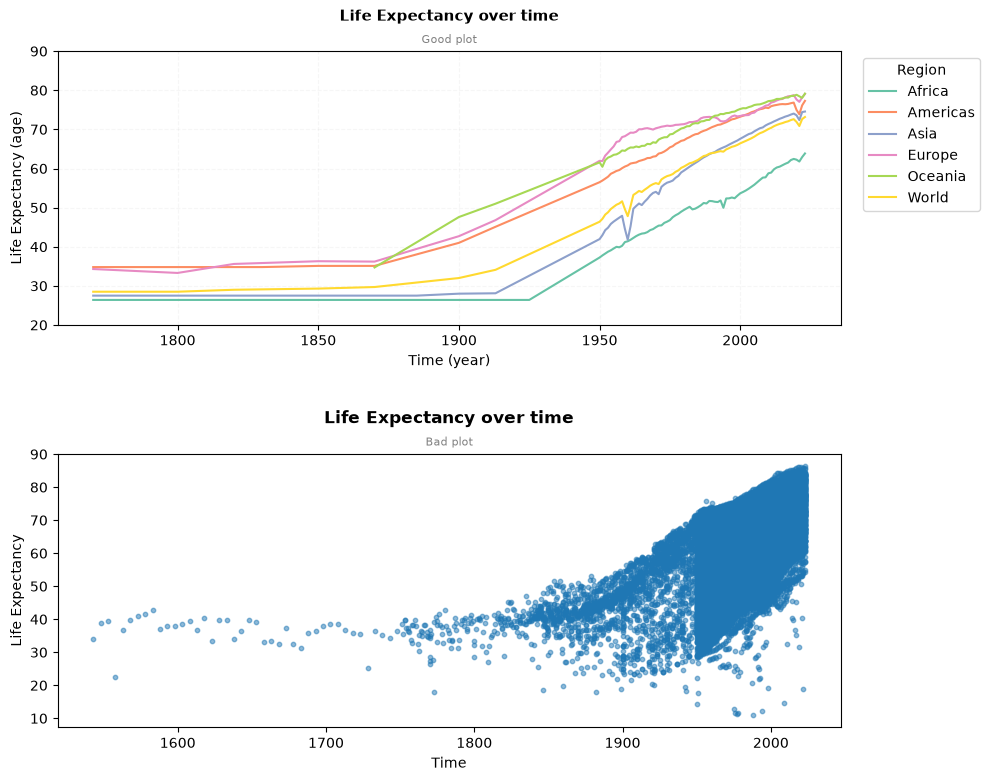

In [154]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
# --- Subplot 0: Life Expectancy ---
ax[0].set_title('Life Expectancy over time', fontsize=11, fontweight='bold', pad=22)
ax[0].text(0.5, 1.02, 'Good plot', transform=ax[0].transAxes, ha='center', va='bottom', fontsize=8, color='gray')
# use seaborn to make i viusally nicer
sns.lineplot(data=df_life_filtered, x='Year', y='Life expectancy', hue='Entity', palette='Set2', linewidth=1.5,ax=ax[0])
ax[0].grid(True, linestyle='--', alpha=0.1)
ax[0].set_xlabel('Time (year)')
ax[0].set_ylim(20, 90)
ax[0].set_ylabel('Life Expectancy (age)')
ax[0].legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
# --- Subplot 1: GDP per Capita ---
ax[1].set_title('Life Expectancy over time', fontsize=12, fontweight='bold', pad=22)
ax[1].text(0.5, 1.02, 'Bad plot', transform=ax[1].transAxes, ha='center', va='bottom', fontsize=8, color='gray')
ax[1].scatter(life_years, life_var, color='tab:blue', alpha=0.5, s=10) # reduced point size for clearer plot
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Life Expectancy')

# h_pad adds vertical spacing between top and bottom subplots; rect reserves space for suptitle
plt.tight_layout(rect=[0, 0, 1, 0.99], h_pad=3.0)
plt.show()

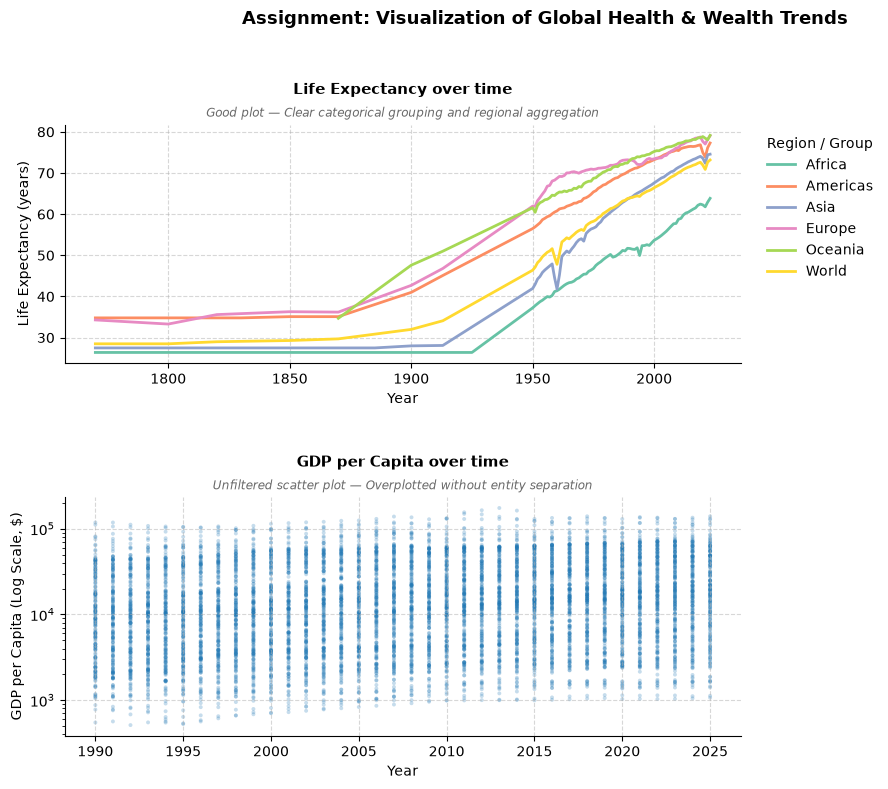

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 1, figsize=(11, 8))
fig.suptitle('Assignment: Visualization of Global Health & Wealth Trends', fontsize=13, fontweight='bold')

# --- Subplot 0: Life Expectancy (Good Plot) ---
ax[0].set_title('Life Expectancy over time', fontsize=11, fontweight='bold', pad=22)
ax[0].text(0.5, 1.02, 'Good plot — Clear categorical grouping and regional aggregation', 
           transform=ax[0].transAxes, ha='center', va='bottom', fontsize=8.5, color='dimgray', fontstyle='italic')

sns.lineplot(
    data=df_life_filtered, 
    x='Year', 
    y='Life expectancy', 
    hue='Entity', 
    palette='Set2', 
    linewidth=2,
    ax=ax[0]
)

ax[0].set_xlabel('Year', fontsize=10)
ax[0].set_ylabel('Life Expectancy (years)', fontsize=10)
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].legend(title="Region / Group", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

# --- Subplot 1: GDP per Capita (Bad Plot Improvement) ---
ax[1].set_title('GDP per Capita over time', fontsize=11, fontweight='bold', pad=22)
ax[1].text(0.5, 1.02, 'Unfiltered scatter plot — Overplotted without entity separation', 
           transform=ax[1].transAxes, ha='center', va='bottom', fontsize=8.5, color='dimgray', fontstyle='italic')

ax[1].scatter(gdp_years, gdp_var, color='tab:blue', alpha=0.25, s=8, edgecolors='none')
ax[1].set_yscale('log')  # Log scale transforms exponential curves to readable linear trends
ax[1].set_xlabel('Year', fontsize=10)
ax[1].set_ylabel('GDP per Capita (Log Scale, $)', fontsize=10)
ax[1].grid(True, linestyle='--', alpha=0.5)

# Clean up top/right spines across both plots
sns.despine(fig=fig)

# Adjust rect to leave 18% right margin for the legend and top space for suptitle
plt.tight_layout(rect=[0, 0, 0.82, 0.95], h_pad=3.5)
plt.show()